In [27]:
import text_to_netcdf as txt2nc
import matplotlib.pyplot as plt
import cmocean.cm as cm
import numpy as np

In [5]:
folderPath = "/Users/madelinemamer/Documents/PIV_demo/PIVLAB_files/"
ds = txt2nc.text_to_netcdf(folderPath)

File count: 2    |   Total Storage: 1.718746 MB
Created xarray dataset. Total storage: 0.799648 MB.   |   Reduction in storage : 0.4652508282201093


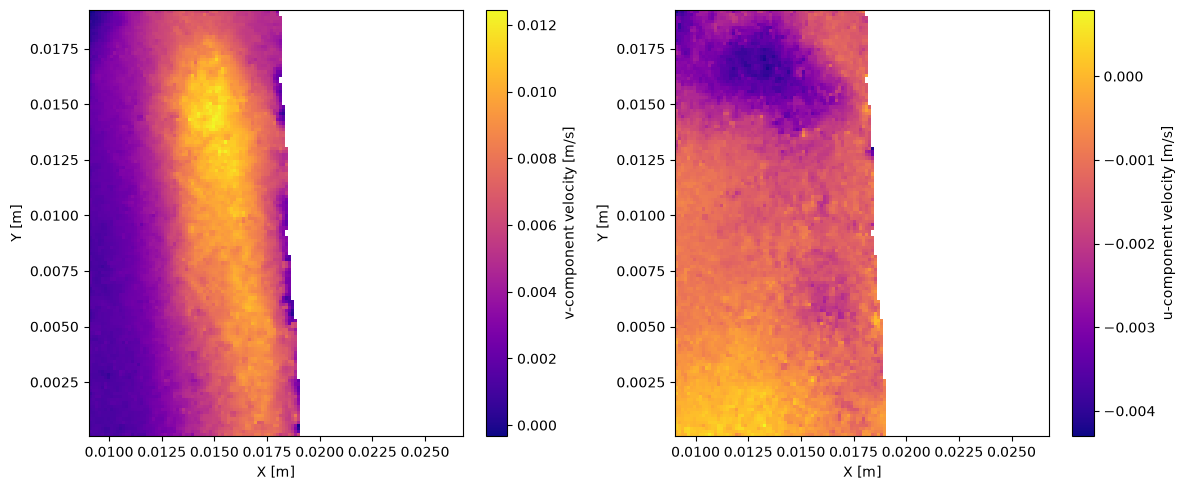

In [ ]:
# Plot the mean velocity
fig, ax = plt.subplots(1,2, figsize = (12,5))

c = ax[0].pcolormesh(ds.x, ds.y, ds.v[:,:,:].mean(dim="time"), cmap = 'plasma')
plt.colorbar(c, label = "v-component velocity [m/s]")
ax[0].set_xlabel("X [m]")
ax[0].set_ylabel("Y [m]")

c = ax[1].pcolormesh(ds.x, ds.y, ds.u[:,:,:].mean(dim="time"), cmap = 'plasma')
plt.colorbar(c, label = "u-component velocity [m/s]")
ax[1].set_xlabel("X [m]")
ax[1].set_ylabel("Y [m]")

plt.tight_layout()

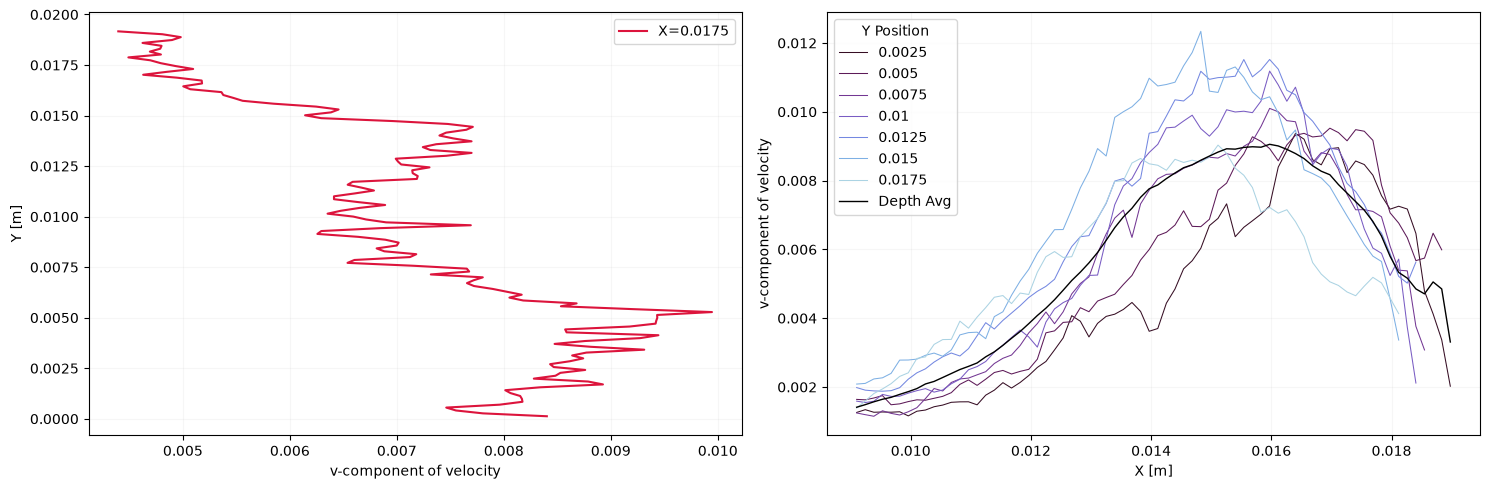

In [43]:
# Plot a slice in x and y
fig, ax = plt.subplots(1,2, figsize = (15,5))



ax[0].plot(ds.v[:,:,:].mean(dim="time").sel(x=0.0175, method="nearest"), ds.y, color = "crimson", label = 'X=0.0175')
ax[0].set_ylabel("Y [m]")
ax[0].set_xlabel("v-component of velocity")
ax[0].grid(alpha = 0.1)
ax[0].legend()

y_slices = np.array([0.0025, 0.005, 0.0075, 0.01, 0.0125, 0.015, 0.0175])
cmap = cm.dense_r(np.linspace(0,1,len(y_slices)+1))

for i in range(len(y_slices)):
    ax[1].plot(ds.x, ds.v[:,:,:].mean(dim="time").sel(y=y_slices[i], method="nearest"), color = cmap[i], label = y_slices[i], linewidth = 0.75)

ax[1].plot(ds.x, ds.v[:,:,:].mean(dim="time").mean(dim="y"), color = 'k', label = "Depth Avg", linewidth = 1)
ax[1].set_xlabel("X [m]")
ax[1].set_ylabel("v-component of velocity")
ax[1].grid(alpha = 0.1)
ax[1].legend(title="Y Position")
plt.tight_layout()